<a href="https://colab.research.google.com/github/liakhariee/Credit-Risk-Binary-Classification/blob/main/credit_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, AdaBoostClassifier, StackingClassifier, VotingClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

import datetime
import joblib

import optuna
import shap

1. person_age - возраст
2. person_income - ежегодный доход в $
3. person_home_ownership 	Home ownership
4. person_emp_length - трудовой стаж
5. loan_intent 	Loan intent
6. loan_grade 	Loan grade
7. loan_amnt - сумма кредита
8. loan_int_rate 	Interest rate
9. **loan_status 	Loan status (0 is non default 1 is default)**
10. loan_percent_income 	Percent income
11. cb_person_default_on_file 	Historical default
12. cb_preson_cred_hist_length 	Credit history length










In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
credit_path = '/content/drive/MyDrive/Обучение/Диплом/credit_risk_dataset.csv'
credit_df = pd.read_csv(credit_path)

In [ ]:
credit_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
credit_df.shape

(32581, 12)

# **Data Cleaning**

In [ ]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
credit_df["loan_intent"].value_counts()

,count
loan_intent,
EDUCATION,6453
MEDICAL,6071
VENTURE,5719
PERSONAL,5521
DEBTCONSOLIDATION,5212
HOMEIMPROVEMENT,3605


In [ ]:
credit_df[credit_df["person_emp_length"].isna()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000,5.42,1,0.16,N,4
222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000,12.42,0,0.19,N,2
379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,NaN,1,0.23,N,3
407,25,52000,RENT,NaN,PERSONAL,B,24000,10.74,1,0.46,N,2
408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250,15.27,0,0.13,Y,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32285,38,12000,OWN,NaN,EDUCATION,A,4800,7.29,1,0.40,N,12
32328,51,18408,RENT,NaN,PERSONAL,C,1000,14.65,1,0.05,Y,20
32360,70,39996,RENT,NaN,MEDICAL,C,3600,15.23,0,0.09,Y,19
32453,56,32400,RENT,NaN,MEDICAL,A,8575,7.51,0,0.26,N,18


In [ ]:
credit_df.groupby("person_age")["person_emp_length"].mean().head()

,person_emp_length
person_age,
20,3.333333
21,3.299660
22,3.653879
23,3.934817
24,4.317800


In [ ]:
credit_df['person_emp_length'] = credit_df.groupby("person_age")["person_emp_length"].transform(
    lambda x: x.fillna(x.mean())
)

In [ ]:
credit_df.groupby("loan_grade")["loan_int_rate"].mean()

,loan_int_rate
loan_grade,
A,7.327651
B,10.995555
C,13.463542
D,15.361448
E,17.009455
F,18.609159
G,20.251525


In [ ]:
credit_df['loan_int_rate'] = credit_df.groupby("loan_grade")["loan_int_rate"].transform(
    lambda x: x.fillna(x.mean())
)

In [ ]:
credit_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.787637,9589.371106,11.009816,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087807,6322.086646,3.219338,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.880000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.995555,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.463542,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
person_age_to_drop_indexes = credit_df[credit_df["person_age"] > 100].index
credit_df = credit_df.drop(index=person_age_to_drop_indexes)

In [ ]:
person_emp_length_to_drop_indexes = credit_df[credit_df["person_emp_length"] > 100].index
credit_df = credit_df.drop(index=person_emp_length_to_drop_indexes)

In [ ]:
credit_df['person_home_ownership'].unique()

array(['OWN', 'MORTGAGE', 'RENT', 'OTHER'], dtype=object)

In [ ]:
credit_cat_df = credit_df.copy()
cat_features = ["cb_person_default_on_file", "loan_grade", "person_home_ownership", "loan_intent"]

In [ ]:
# Кодировка категориальных признаков
# Label Encoding
le_default = LabelEncoder()
le_grade = LabelEncoder()

credit_df["cb_person_default_on_file_encoded"] = le_default.fit_transform(credit_df["cb_person_default_on_file"])
credit_df["loan_grade_encoded"] = le_grade.fit_transform(credit_df["loan_grade"])
credit_df = credit_df.drop(columns=["cb_person_default_on_file", "loan_grade"])
credit_df.head()

joblib.dump(le_default, '/content/drive/MyDrive/Обучение/Диплом/le_default_encoder.pkl')
joblib.dump(le_grade, '/content/drive/MyDrive/Обучение/Диплом/le_grade_encoder.pkl')

['/content/drive/MyDrive/Обучение/Диплом/le_grade_encoder.pkl']

In [ ]:
credit_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,cb_person_default_on_file_encoded,loan_grade_encoded
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,2,0,1
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,3,0,2
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,2,0,2
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,4,1,2
5,21,9900,OWN,2.0,VENTURE,2500,7.14,1,0.25,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,5800,13.16,0,0.11,30,0,2
32577,54,120000,MORTGAGE,4.0,PERSONAL,17625,7.49,0,0.15,19,0,0
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,35000,10.99,1,0.46,28,0,1
32579,56,150000,MORTGAGE,5.0,PERSONAL,15000,11.48,0,0.10,26,0,1


In [ ]:
# One Hot Encoding
ohe = OneHotEncoder(sparse_output=False)
ohe_columns = ["person_home_ownership", "loan_intent"]
ohencoded_features = ohe.fit_transform(credit_df[ohe_columns])
ohe_df = pd.DataFrame(ohencoded_features, columns=ohe.get_feature_names_out(ohe_columns), index=credit_df.index)
credit_df = pd.concat([credit_df, ohe_df], axis=1)
credit_df = credit_df.drop(columns=ohe_columns)

joblib.dump(ohe, '/content/drive/MyDrive/Обучение/Диплом/ohe_encoder.pkl')

['/content/drive/MyDrive/Обучение/Диплом/ohe_encoder.pkl']

In [ ]:
credit_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,cb_person_default_on_file_encoded,loan_grade_encoded,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
count,32574.000000,3.257400e+04,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000
mean,27.718426,6.587848e+04,4.780224,9588.018051,11.009666,0.218180,0.170202,5.804108,0.176337,1.218149,0.412630,0.003285,0.079327,0.504758,0.160005,0.198041,0.110671,0.186376,0.169430,0.175477
std,6.204987,5.253194e+04,3.981665,6320.249598,3.219418,0.413017,0.106755,4.053873,0.381112,1.166382,0.492315,0.057220,0.270253,0.499985,0.366616,0.398530,0.313729,0.389415,0.375137,0.380381
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.880000,0.000000,0.090000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.995555,0.000000,0.150000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.463542,0.000000,0.230000,8.000000,0.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# **Correlations**

In [ ]:
X = credit_df.copy()
y = X.pop('loan_status')

In [ ]:
correlations = X.corrwith(y, method='pearson')
correlations = correlations.sort_values(ascending=False)
correlations

,0
loan_percent_income,0.379250
loan_grade_encoded,0.373042
loan_int_rate,0.333648
person_home_ownership_RENT,0.238416
cb_person_default_on_file_encoded,0.179002
loan_amnt,0.105240
loan_intent_DEBTCONSOLIDATION,0.071540
loan_intent_MEDICAL,0.056582
loan_intent_HOMEIMPROVEMENT,0.036596
person_home_ownership_OTHER,0.012542


In [ ]:
mi_scores = mutual_info_classif(X, y)
mi_scores = pd.Series(mi_scores, name="MI scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

,MI scores
person_income,0.114729
loan_percent_income,0.082880
loan_grade_encoded,0.077067
loan_int_rate,0.075430
person_home_ownership_RENT,0.032803
person_home_ownership_MORTGAGE,0.019287
loan_amnt,0.015049
cb_person_default_on_file_encoded,0.014762
loan_intent_PERSONAL,0.006896
person_home_ownership_OWN,0.006494


# **Fitting**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [ ]:
def fit_model(model_classifier, X_train, y_train, X_test, y_test):
    start = datetime.datetime.now()

    model = model_classifier(random_state=42)
    model.fit(X_train, y_train)
    model_predictions = model.predict(X_test)
    model_predictions_proba = model.predict_proba(X_test)[:, 1]

    finish = datetime.datetime.now()

    print(f"""
    Модель: {model_classifier}
    Время работы: {str(finish - start)}
    confusion matrix: \n{confusion_matrix(y_test, model_predictions)}
    accuracy: {round(accuracy_score(y_test, model_predictions), 4)}
    precision: {round(precision_score(y_test, model_predictions), 4)}
    recall: {round(recall_score(y_test, model_predictions), 4)}
    f1: {round(f1_score(y_test, model_predictions), 4)}
    roc_auc_score: {round(roc_auc_score(y_test, model_predictions_proba), 4)}
    """)

models = [RandomForestClassifier, GradientBoostingClassifier, lgb.LGBMClassifier, xgb.XGBClassifier, CatBoostClassifier, BaggingClassifier, AdaBoostClassifier]

for model in models:
    fit_model(model, X_train, y_train, X_test, y_test)


KeyboardInterrupt: 

In [ ]:
X_cat = credit_cat_df.copy()
y_cat = X_cat.pop('loan_status')

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42, shuffle=True, stratify=y)

start = datetime.datetime.now()

model = CatBoostClassifier(random_state=42, cat_features=cat_features, verbose=0)
model.fit(X_cat_train, y_cat_train)
model_predictions = model.predict(X_cat_test)
model_predictions_proba = model.predict_proba(X_cat_test)[:, 1]

finish = datetime.datetime.now()

print(f"""
Модель: {model}
Время работы: {str(finish - start)}

roc_auc_score: {round(roc_auc_score(y_test, model_predictions_proba), 4)}
confusion matrix: \n{confusion_matrix(y_test, model_predictions)}
accuracy: {round(accuracy_score(y_test, model_predictions), 4)}
precision: {round(precision_score(y_test, model_predictions), 4)}
recall: {round(recall_score(y_test, model_predictions), 4)}
f1: {round(f1_score(y_test, model_predictions), 4)}
""")


In [ ]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 20)
    max_leaves = trial.suggest_int('max_leaves', 10, 100)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.5, log=True)
    reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True)
    reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])
    min_child_weight = trial.suggest_int('min_child_weight', 1, 20)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_index, val_index in kf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        default_ratio = len(y_tr[y_tr == 0]) / len(y_tr[y_tr == 1])

        classifier = xgb.XGBClassifier(
            n_estimators=1000,
            max_depth=max_depth,
            max_leaves=max_leaves,
            grow_policy=grow_policy,
            learning_rate=learning_rate,
            scale_pos_weight=default_ratio,
            min_child_weight=min_child_weight,
            verbosity=0,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            eval_metric='auc',
            early_stopping_rounds=50,
            random_state=42
        )

        classifier.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        classifier_predictions_proba = classifier.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, classifier_predictions_proba)
        auc_scores.append(roc_auc)

    return np.mean(auc_scores)

study = optuna.create_study(study_name="max_xgb", direction="maximize")
study.optimize(objective, n_trials=500)

print("Лучшие параметры: ", study.best_params)
print("Лучший ROC-AUC (CV): ", study.best_value)

In [ ]:
default_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

final_classifier = xgb.XGBClassifier(
            n_estimators=1000,
            max_depth=14,
            max_leaves=21,
            grow_policy='lossguide',
            learning_rate=0.07032649804656241,
            scale_pos_weight=default_ratio,
            verbosity=0,
            reg_alpha=4.753772000307644,
            reg_lambda=0.008557018203563355,
            eval_metric='auc',
            early_stopping_rounds=50,
            min_child_weight=8,
            random_state=42
        )

final_classifier.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
final_classifier_predictions_proba = final_classifier.predict_proba(X_test)[:, 1]
final_roc_auc = roc_auc_score(y_test, final_classifier_predictions_proba)

print(f"Финальный ROC-AUC на тесте: {final_roc_auc:.4f}")
print(f"Количество использованных деревьев: {final_classifier.best_iteration}")

joblib.dump(final_classifier, '/content/drive/MyDrive/Обучение/Диплом/final_xgb_classifier.pkl')

KeyboardInterrupt: 

In [ ]:
# https://xgboost.readthedocs.io/en/stable/python/python_intro.html
#xgb.plot_importance(final_classifier)
xgb.plot_tree(final_classifier, num_trees=2)

In [ ]:
feature_names = final_classifier.feature_names_in_
feature_importances = final_classifier.feature_importances_

feature_importance_dict = dict(zip(feature_names, feature_importances))
feature_importance_df = pd.DataFrame.from_dict(
    feature_importance_dict, orient='index', columns=['Importance']
    )
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Importance
loan_grade_encoded,0.292612
person_home_ownership_RENT,0.134716
loan_percent_income,0.122381
person_home_ownership_OWN,0.077724
loan_intent_VENTURE,0.076188
loan_intent_MEDICAL,0.058187
loan_intent_DEBTCONSOLIDATION,0.049981
loan_intent_HOMEIMPROVEMENT,0.048796
person_income,0.032820
person_home_ownership_MORTGAGE,0.026278


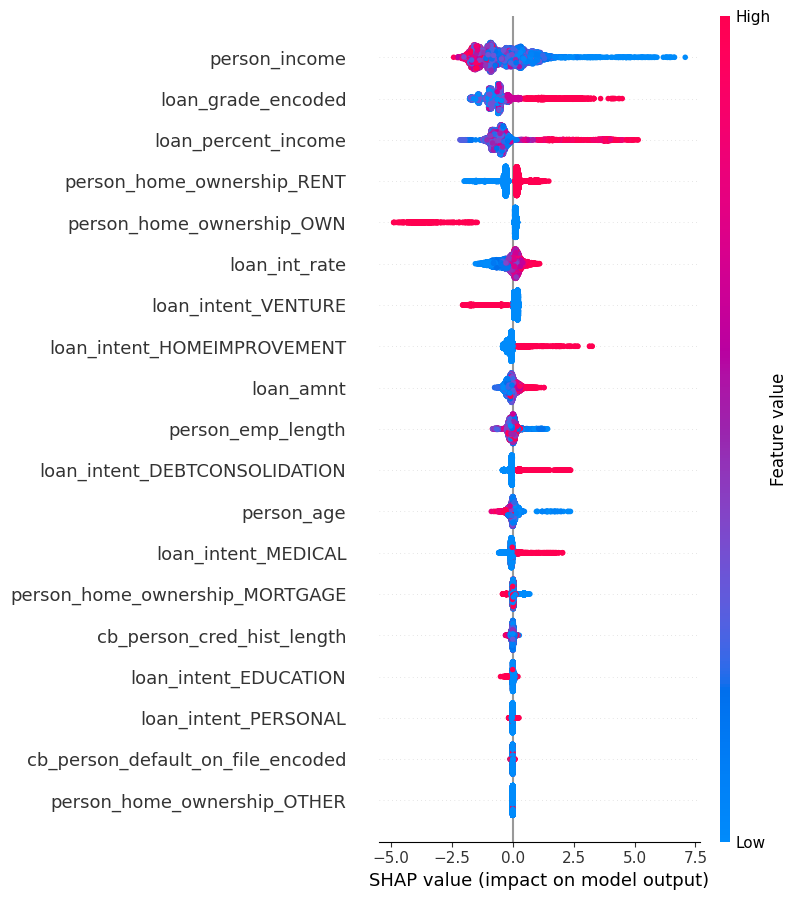

In [ ]:
explainer = shap.Explainer(final_classifier)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
le_default = joblib.load('/content/drive/MyDrive/Обучение/Диплом/le_default_encoder.pkl')
le_grade = joblib.load('/content/drive/MyDrive/Обучение/Диплом/le_grade_encoder.pkl')
ohe = joblib.load('/content/drive/MyDrive/Обучение/Диплом/ohe_encoder.pkl')
final_classifier = joblib.load('/content/drive/MyDrive/Обучение/Диплом/final_xgb_classifier.pkl')

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


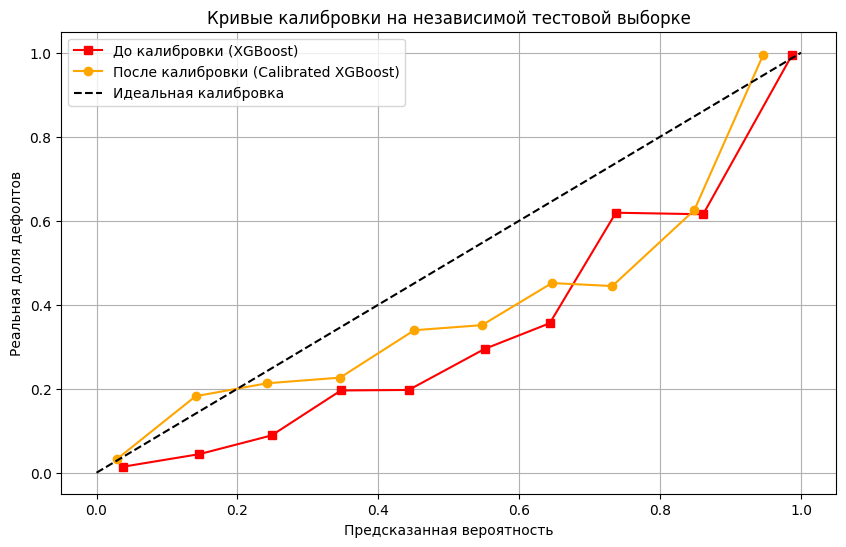

ROC-AUC до калибровки: 0.9511 | после: 0.9511
Brier Score до калибровки: 0.0644 | после: 0.0544


['/content/drive/MyDrive/Обучение/Диплом/calibrated_clf.pkl']

In [ ]:
X_calib, X_final_test, y_calib, y_final_test = train_test_split(
    X_test, y_test,
    test_size=0.5,
    random_state=42,
    stratify=y_test
)

calibrated_clf = CalibratedClassifierCV(final_classifier, method='sigmoid', cv='prefit')
calibrated_clf.fit(X_calib, y_calib)

y_prob_uncalibrated = final_classifier.predict_proba(X_final_test)[:, 1]
y_prob_calibrated = calibrated_clf.predict_proba(X_final_test)[:, 1]

frac_uncal, mean_val_uncal = calibration_curve(y_final_test, y_prob_uncalibrated, n_bins=10)
frac_cal, mean_val_cal = calibration_curve(y_final_test, y_prob_calibrated, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot(mean_val_uncal, frac_uncal, "s-", label="До калибровки (XGBoost)", color='red')
plt.plot(mean_val_cal, frac_cal, "o-", label="После калибровки (Calibrated XGBoost)", color='orange')
plt.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка")
plt.xlabel("Предсказанная вероятность")
plt.ylabel("Реальная доля дефолтов")
plt.title("Кривые калибровки на независимой тестовой выборке")
plt.legend()
plt.grid(True)
plt.show()

auc_before = roc_auc_score(y_final_test, y_prob_uncalibrated)
auc_after = roc_auc_score(y_final_test, y_prob_calibrated)

brier_before = brier_score_loss(y_final_test, y_prob_uncalibrated)
brier_after = brier_score_loss(y_final_test, y_prob_calibrated)

print(f"ROC-AUC до калибровки: {auc_before:.4f} | после: {auc_after:.4f}")
print(f"Brier Score до калибровки: {brier_before:.4f} | после: {brier_after:.4f}")

joblib.dump(calibrated_clf, '/content/drive/MyDrive/Обучение/Диплом/calibrated_clf.pkl')

Вероятность дефолта для клиента: 0.2674 (26.74%)


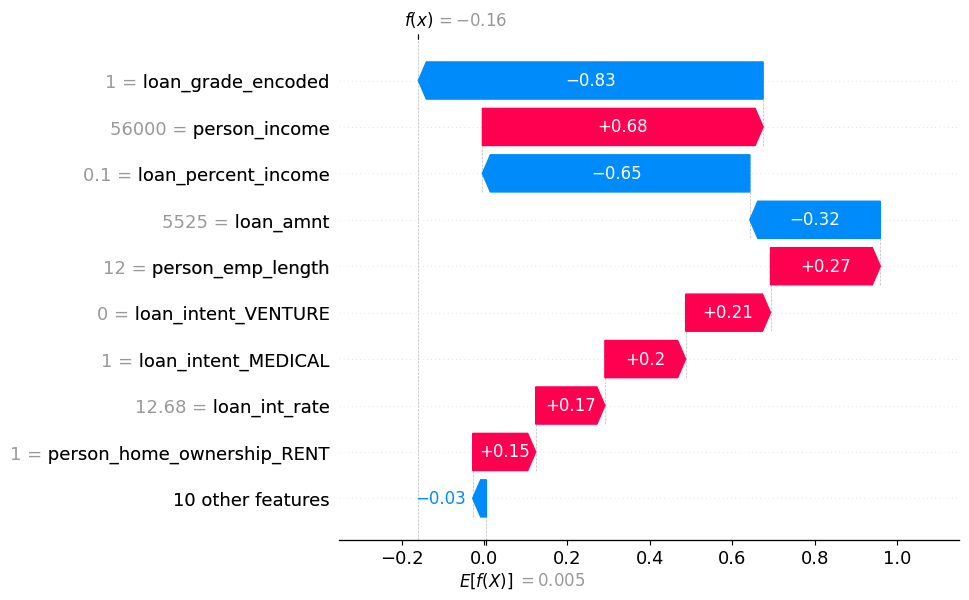

In [ ]:
client_data = {
    'person_age': [28],
    'person_income': [56000],
    'person_home_ownership': ['RENT'],
    'person_emp_length': [12],
    'loan_intent': ['MEDICAL'],
    'loan_grade': ['B'],
    'loan_amnt': [5525],
    'loan_int_rate': [12.68],
    'loan_percent_income': [0.10],
    'cb_person_default_on_file': ['N'],
    'cb_person_cred_hist_length': [9]
}

client_df = pd.DataFrame(client_data)

client_df['loan_grade_encoded'] = le_grade.transform(client_df['loan_grade'])
client_df['cb_person_default_on_file_encoded'] = le_default.transform(client_df['cb_person_default_on_file'])

client_df = client_df.drop(columns=['loan_grade', 'cb_person_default_on_file'])

ohe_features = ohe.transform(client_df[['person_home_ownership', 'loan_intent']])
ohe_columns_names = ohe.get_feature_names_out(['person_home_ownership', 'loan_intent'])
ohe_client_df = pd.DataFrame(ohe_features, columns=ohe_columns_names, index=client_df.index)

client_df = pd.concat([client_df, ohe_client_df], axis=1)

client_df = client_df.drop(columns=['person_home_ownership', 'loan_intent'])

client_processed = client_df[calibrated_clf.feature_names_in_]

prob_defolt = calibrated_clf.predict_proba(client_processed)[0][1]
print(f"Вероятность дефолта для клиента: {prob_defolt:.4f} ({prob_defolt*100:.2f}%)")

explainer = shap.Explainer(calibrated_clf.estimator)
shap_values = explainer(client_processed)

shap.plots.waterfall(shap_values[0], max_display=10, show=True)

https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

https://xgboosting.com/xgboost-tune-scale_pos_weight-parameter/